# Intro

This Tutorial conducts external information-based evaluation of ARGEN in contrast to other baseline methods, Naive GLM and INSPRE. This reproduces Fig.5c,d of the manuscript.

In [1]:
if (!requireNamespace("pacman", quietly = TRUE)) install.packages("pacman", repos = "https://cloud.r-project.org")

pacman::p_load(
  here, dplyr, data.table,ggplot2,scales,GenomicRanges,ggpubr,purrr,tidyr
)

DIR <- here::here()   # resolves to the repo root automatically


# Read in Gene location information

In [2]:
gene_tbl=readRDS(paste0(DIR,'/data/auxiliary/gene_tbl.rds'))

# Fit Naive GLM method

In [3]:
chrlist=paste0('chr',c(1:22,"X"))
# ---------------- summarizing ----------------
edges_from_dagsearch <- function(dag_obj) {
  out <- lapply(dag_obj$edge_structure, function(df) if (is.null(df) || !nrow(df)) NULL else df[complete.cases(df), , drop=FALSE])
  out <- do.call(rbind, out)
  if (is.null(out) || !nrow(out)) data.frame(from=character(0), to=character(0), coef=numeric(0)) else unique(out)
}

compute_ancestors_map <- function(nodes, edges_df) {
  parents_map <- setNames(lapply(nodes, function(nm) character(0)), nodes)
  if (nrow(edges_df)) { split_by_to <- split(edges_df$from, edges_df$to); for (to in names(split_by_to)) parents_map[[to]] <- unique(split_by_to[[to]]) }
  ancestors <- setNames(lapply(nodes, function(nm) character(0)), nodes)
  changed <- TRUE
  while (changed) {
    changed <- FALSE
    for (v in nodes) {
      cur <- ancestors[[v]]
      new <- unique(c(parents_map[[v]], unlist(ancestors[parents_map[[v]]], use.names=FALSE)))
      new <- setdiff(new, v)
      if (length(setdiff(new, cur)) > 0) { ancestors[[v]] <- unique(c(cur, new)); changed <- TRUE }
    }
  }
  list(parents_map=parents_map, ancestors_map=ancestors)
}


In [4]:
source(paste0(DIR,'/code/function/Proxy_IV_functions_parallel.R'))
source(paste0(DIR,'/code/function/inspre.R'))
Rcpp::sourceCpp(paste0(DIR,'/code/function/inspre_cpp.cpp'))


for(chr in 1:23){
  set.seed(1)
  
  # -------------------------------
  # Paths / output
  # -------------------------------
  DAG_DIR <- paste0(DIR,'/results/application/chr_specific/',chrlist[chr])
  if (!dir.exists(DAG_DIR)) dir.create(DAG_DIR, recursive = TRUE, showWarnings = FALSE)
  
  # -------------------------------
  # Load data (your paths)
  # -------------------------------
  X_raw  <- readRDS(paste0(DIR,'/data/chr_specific/',chrlist[chr],"/X_raw_",chrlist[chr],'.rds'))
  meta_data <- readRDS(paste0(DIR,'/data/chr_specific/',chrlist[chr],"/meta_data_",chrlist[chr],'.rds'))
  
  # Design matrix D (exactly as you had)
  perturbation_unique <- unique(meta_data$gene_id)
  meta_data$gene_id <- factor(meta_data$gene_id,
                                            levels = unique(meta_data$gene_id))
  meta_data$gem_group<-factor(meta_data$gem_group)
  
  D <- model.matrix(~ gene_id - 1, data = meta_data)
  colnames(D) <- sub("^gene_id", "", colnames(D))
  D <- D[, -c(length(perturbation_unique))]  # keep your exclusion
  control_ind <- which(rowSums(D) == 0)
  
  # Offset vector (depth)
  C <- meta_data$guide_UMI_sum / mean(meta_data$guide_UMI_sum)
  
  
  # Basic checks
  nodes <- colnames(X_raw)
  p <- length(nodes)
  options(future.globals.maxSize = 10 * 1024^3) 

# use the same descendant set as in ARGEN    
setwd(DAG_DIR)
ds_out=readRDS('ds_out_covadjust.rds')
    
  
  dag_obj <- dag_search_perturbseq_Naive(
    desc_sets = ds_out$descendant_set_score_closure,data_raw = X_raw,
    D = D, depth = C, family = "poisson",
    cc_df = data.frame(meta_data),  cc_cols = c('mitopercent'),
    alpha_parent = 0.05, padj_method_parent = "onlineBH"
  )
  
  
  edges_k <- edges_from_dagsearch(dag_obj)
  maps_k  <- compute_ancestors_map(nodes, edges_k)
  dag_artifact <- list(
    dag_object    = dag_obj,
    dag_edges     = edges_k,
    parents_map   = maps_k$parents_map,
    ancestors_map = maps_k$ancestors_map
  )
  
  setwd(DAG_DIR)  
  saveRDS(dag_artifact, file = file.path(DAG_DIR,  'Naive_dag_0.05BH_0.05onlineBH.rds'))
  
  
  
  
  print(paste0(chr," complete!"))
  
}




[1] 86
[1] 85
[1] 84
[1] 83
[1] 82
[1] 81
[1] 80
[1] 79
[1] 78
[1] 77
[1] 76
[1] 75
[1] 74
[1] 73
[1] 72
[1] 71
[1] 70
[1] 69
[1] 68
[1] 67
[1] 66
[1] 65
[1] 64
[1] 63
[1] 62
[1] 61
[1] 60
[1] 59
[1] 58
[1] 57
[1] 56
[1] 55
[1] 54
[1] 53
[1] 52
[1] 51
[1] 50
[1] 49
[1] 48
[1] 47
[1] 46
[1] 45
[1] 44
[1] 43
[1] 42
[1] 41
[1] 40
[1] 39
[1] 38
[1] 37
[1] 36
[1] 35
[1] 34
[1] 33
[1] 32
[1] 31
[1] 30
[1] 29
[1] 28
[1] 27
[1] 26
[1] 25
[1] 24
[1] 23
[1] 22
[1] 21
[1] 20
[1] 19
[1] 18
[1] 17
[1] 16
[1] 15
[1] 14
[1] 13
[1] 12
[1] 11
[1] 10
[1] 9
[1] 8
[1] 7
[1] 6
[1] 5
[1] 4
[1] 3
[1] 2
[1] 1
[1] "1 complete!"
[1] 67
[1] 66
[1] 65
[1] 64
[1] 63
[1] 62
[1] 61
[1] 60
[1] 59
[1] 58
[1] 57
[1] 56
[1] 55
[1] 54
[1] 53
[1] 52
[1] 51
[1] 50
[1] 49
[1] 48
[1] 47
[1] 46
[1] 45
[1] 44
[1] 43
[1] 42
[1] 41
[1] 40
[1] 39
[1] 38
[1] 37
[1] 36
[1] 35
[1] 34
[1] 33
[1] 32
[1] 31
[1] 30
[1] 29
[1] 28
[1] 27
[1] 26
[1] 25
[1] 24
[1] 23
[1] 22
[1] 21
[1] 20
[1] 19
[1] 18
[1] 17
[1] 16
[1] 15
[1] 14
[1] 13
[1] 

# evaluation of edges TADs (Fig. 5c)

## Gene location information and required functions

In [4]:
strip_ver <- function(x) sub("\\.\\d+$","", x)
  if (!"gene_id_nover" %in% names(gene_tbl)) {
    gene_tbl$gene_id_nover <- strip_ver(gene_tbl$gene_id)
  }

make_null_uniform <- function(nodes, E_called, m = length(E_called), seed = 1) {
  set.seed(seed)
  # all directed pairs except self-loops
  all_pairs <- expand.grid(from = nodes, to = nodes, stringsAsFactors = FALSE)
  all_pairs <- subset(all_pairs, from != to)
  # exclude called edges
  all_pairs$key <- paste0(all_pairs$from, "->", all_pairs$to)
  pool <- subset(all_pairs, !(key %in% E_called))
  if (nrow(pool) < m) stop("Not enough edges in the background pool to sample.")
  samp <- pool[sample.int(nrow(pool), m, replace = FALSE), c("from","to")]
  rownames(samp) <- NULL
  samp
}


overlap_TAD_fun=function(df){
    
    # ---- 1. Build GRanges for genes and TADs ----
gr_from <- GRanges(
  seqnames = df$chr_from,
  ranges   = IRanges(start = df$tss_from, width = 1),
  gene     = df$from
)

gr_to <- GRanges(
  seqnames = df$chr_from,
  ranges   = IRanges(start = df$tss_to, width = 1),
  gene     = df$to
)

gr_TADs <- GRanges(
  seqnames = TADs$chr,
  ranges   = IRanges(start = TADs$start, end = TADs$end)
)

# ---- 2. Find overlaps of from/to TSS with TADs ----
from_hits <- findOverlaps(gr_from, gr_TADs) %>%
  as.data.frame() %>%
  dplyr::rename(row_id = queryHits, tad_from_idx = subjectHits) %>%
  mutate(
    tad_from_start = start(gr_TADs)[tad_from_idx],
    tad_from_end   = end(gr_TADs)[tad_from_idx]
  )

to_hits <- findOverlaps(gr_to, gr_TADs) %>%
  as.data.frame() %>%
  dplyr::rename(row_id = queryHits, tad_to_idx = subjectHits) %>%
  mutate(
    tad_to_start = start(gr_TADs)[tad_to_idx],
    tad_to_end   = end(gr_TADs)[tad_to_idx]
  )

# ---- 3. Merge with df ----
df_TAD <- df %>%
  mutate(row_id = row_number()) %>%
  left_join(from_hits, by = "row_id") %>%
  left_join(to_hits,   by = "row_id") %>%
  mutate(same_TAD = tad_from_idx == tad_to_idx)

# ---- 4. Check output ----
df_TAD=df_TAD %>%
  dplyr::select(chr_from, from, to, tss_from, tss_to,
         tad_from_start, tad_from_end,
         tad_to_start, tad_to_end, same_TAD) 

# ---- 5. Summarize for each regulator ----
summary_TAD <- df_TAD  %>%
  group_by(from) %>%
  summarise(
    total_targets = n(),
    same_TAD_targets = sum(same_TAD, na.rm = TRUE),
    prop_same_TAD = same_TAD_targets / total_targets
  ) %>%
  arrange(desc(prop_same_TAD))
   return(summary_TAD) 
}


## Reading in fitting results for all the methods including ARGEN.

In [5]:
chrlist=paste0('chr',c(1:22,"X"))
true_edges=c()
all_edges=c()
null_edges=c()
inspre_edges=c()
Naive_edges=c()
for(chr in 1:23){
chrlist=paste0('chr',c(1:22,"X"))
DAG_DIR <- paste0(DIR,'/results/application/chr_specific/',chrlist[chr])
setwd(DAG_DIR)
dag_artifact=readRDS(file = 'dag_0.05BH_0.05onlineBH.rds')
true_edges=rbind(true_edges,dag_artifact$dag_edges)
    
all_edges_chr=do.call('rbind',dag_artifact$dag_object$edge_structure_all)    
all_edges=rbind(all_edges,all_edges_chr)

    
nodes    <- sort(unique(c(all_edges_chr$from, all_edges_chr$to)))
E_called <- paste0(all_edges_chr$from, "->", all_edges_chr$to)    
    
null_pairs <- make_null_uniform(nodes, E_called, m = nrow(all_edges_chr), seed = 1)

# 3) Return as a data.frame with the same columns; fill coef/p_raw as NA (or any placeholders you prefer)
null_df <- transform(null_pairs, coef = 0, p_raw = 1)    
null_edges=rbind(null_edges,null_df)
    
if(chr!=13){
    
dag_artifact_inspre=readRDS(file = paste0('result_INSPRE.rds'))
inspre_edges=rbind(inspre_edges,do.call('rbind',dag_artifact_inspre$edge_structure))    
}

dag_artifact_Naive=readRDS(file = paste0('Naive_dag_0.05BH_0.05onlineBH.rds'))
Naive_edges=rbind(Naive_edges,dag_artifact_Naive$dag_edges)

}

true_edges=true_edges %>% mutate(edge_id=paste0(from,'_',to))
Naive_edges=Naive_edges %>% mutate(edge_id=paste0(from,'_',to))
null_edges=null_edges %>% mutate(edge_id=paste0(from,'_',to))
all_edges=all_edges %>% mutate(edge_id=paste0(from,'_',to))
inspre_edges=inspre_edges%>% mutate(edge_id=paste0(from,'_',to))
inspre_edges$p_raw=1
all_edges_and_null=rbind(all_edges,null_edges)



## Summarizing Null edges

In [6]:
edges=all_edges_and_null
edges <- edges %>% dplyr::rename(from = 1, to = 2)

# Reduce gene_tbl to one row per gene_id_nover and keep needed cols
gt <- gene_tbl %>%
  distinct(gene_id_nover, .keep_all = TRUE) %>%
  dplyr::select(gene_id_nover, chr, tss)

# Join twice: once for "from", once for "to"
edges_annot_all <- edges %>%
  left_join(gt %>% dplyr::rename(chr_from = chr, tss_from = tss),
            by = c("from" = "gene_id_nover")) %>%
  left_join(gt %>% dplyr::rename(chr_to = chr, tss_to = tss),
            by = c("to"   = "gene_id_nover")) %>%
  dplyr::select(from, to, chr_from, tss_from, chr_to, tss_to, coef, p_raw,edge_id)
edges_annot_all=edges_annot_all %>% na.omit

df_all=edges_annot_all %>% dplyr::select(c('chr_to','chr_from','tss_from','tss_to','from','to','p_raw','edge_id'))

df_all=df_all %>% mutate(true_edge=edge_id%in%true_edges$edge_id)
df_all=df_all %>% mutate(null_edge=edge_id%in%null_edges$edge_id)

## Summarizing INSPRE edges

In [7]:
edges=inspre_edges
edges <- edges %>% dplyr::rename(from = 1, to = 2)

# Reduce gene_tbl to one row per gene_id_nover and keep needed cols
gt <- gene_tbl %>%
  distinct(gene_id_nover, .keep_all = TRUE) %>%
  dplyr::select(gene_id_nover, chr, tss)

# Join twice: once for "from", once for "to"
edges_annot_all <- edges %>%
  left_join(gt %>% dplyr::rename(chr_from = chr, tss_from = tss),
            by = c("from" = "gene_id_nover")) %>%
  left_join(gt %>% dplyr::rename(chr_to = chr, tss_to = tss),
            by = c("to"   = "gene_id_nover")) %>%
  dplyr::select(from, to, chr_from, tss_from, chr_to, tss_to, coef, p_raw,edge_id)
edges_annot_all=edges_annot_all %>% na.omit

df_inspre=edges_annot_all %>% dplyr::select(c('chr_to','chr_from','tss_from','tss_to','from','to','p_raw','edge_id'))

## Summarizing Naive GLM edges

In [8]:
edges=Naive_edges
edges <- edges %>% dplyr::rename(from = 1, to = 2)

# Reduce gene_tbl to one row per gene_id_nover and keep needed cols
gt <- gene_tbl %>%
  distinct(gene_id_nover, .keep_all = TRUE) %>%
  dplyr::select(gene_id_nover, chr, tss)

# Join twice: once for "from", once for "to"
edges_annot_all <- edges %>%
  left_join(gt %>% dplyr::rename(chr_from = chr, tss_from = tss),
            by = c("from" = "gene_id_nover")) %>%
  left_join(gt %>% dplyr::rename(chr_to = chr, tss_to = tss),
            by = c("to"   = "gene_id_nover")) %>%
  dplyr::select(from, to, chr_from, tss_from, chr_to, tss_to, coef, p_raw,edge_id)
edges_annot_all=edges_annot_all %>% na.omit

df_Naive=edges_annot_all %>% dplyr::select(c('chr_to','chr_from','tss_from','tss_to','from','to','p_raw','edge_id'))

## Merging TAD information with the edge information across methods

In [9]:
df_filtered=(df_all%>% filter(abs(tss_from-tss_to)<2000000))
df_insre_filtered=(df_inspre%>% filter(abs(tss_from-tss_to)<2000000))
df_Naive_filtered=(df_Naive%>% filter(abs(tss_from-tss_to)<2000000))

sum_notsig=c()
sum_sig=c()
sum_null=c()
sum_inspre=c()
sum_Naive=c()

setwd(paste0(DIR,'/data/TAD'))
for(chr in 1:23){

chrom=chrlist[chr]

OUT_TADS <- paste0(chrlist[chr],"_tads_topdom_coarse_0.1Mb.tsv")    
TADs=fread(OUT_TADS)
   

df=df_filtered %>% filter(chr_to==chrom&true_edge&!null_edge)
df=df %>% dplyr::select('chr_from','tss_from','tss_to','from','to') %>% distinct
numtab=df %>% group_by(from) %>% summarise(num=n()) %>% arrange(desc(num))

df=df %>% filter(from%in%numtab$from)    

df_f=df_filtered %>% filter(chr_to==chrom&!true_edge&!null_edge)
df_f=df_f %>% dplyr::select('chr_from','tss_from','tss_to','from','to') %>% distinct

df_f=df_f %>% filter(from%in%numtab$from)

    
df_n=df_filtered %>% filter(chr_to==chrom&null_edge)
df_n=df_n %>% dplyr::select('chr_from','tss_from','tss_to','from','to') %>% distinct

df_n=df_n %>% filter(from%in%numtab$from)
    
df_ins=df_insre_filtered%>% dplyr::select('chr_from','tss_from','tss_to','from','to') %>% distinct    
df_ins=df_ins %>% filter(from%in%numtab$from)    

df_Naive=df_Naive_filtered%>% dplyr::select('chr_from','tss_from','tss_to','from','to') %>% distinct    
df_Naive=df_Naive %>% filter(from%in%numtab$from)    
    
    
    

sum_sig=rbind(sum_sig,overlap_TAD_fun(df))
sum_notsig=rbind(sum_notsig,overlap_TAD_fun(df_f))
sum_null=rbind(sum_null,overlap_TAD_fun(df_n))    
sum_inspre=rbind(sum_inspre,overlap_TAD_fun(df_ins))
sum_Naive=rbind(sum_Naive,overlap_TAD_fun(df_Naive))    

# ---- 1. Build GRanges for genes and TADs ----


}

colnames(sum_notsig)[4]='prop_same_TAD_notsig'
colnames(sum_null)[4]='prop_same_TAD_null'
colnames(sum_inspre)[4]='prop_same_TAD_inspre'
colnames(sum_Naive)[4]='prop_same_TAD_Naive'
sum_all=merge(sum_sig,sum_notsig[,c(1,4)],by='from',all=TRUE,)
sum_all=merge(sum_all,sum_null[,c(1,4)],by='from',all=TRUE,)
sum_all=merge(sum_all,sum_inspre[,c(1,4)],by='from',all=TRUE,)
sum_all=merge(sum_all,sum_Naive[,c(1,4)],by='from',all=TRUE,)


sum_all$prop_same_TAD_notsig[is.na(sum_all$prop_same_TAD_notsig)]=0
sum_all$prop_same_TAD_null[is.na(sum_all$prop_same_TAD_null)]=0
sum_all$prop_same_TAD_inspre[is.na(sum_all$prop_same_TAD_inspre)]=0
sum_all$prop_same_TAD_Naive[is.na(sum_all$prop_same_TAD_Naive)]=0
sum_all_nonzero=sum_all %>% filter(!(prop_same_TAD==0&prop_same_TAD_notsig==0&prop_same_TAD_null==0
                                    &prop_same_TAD_inspre==0&prop_same_TAD_Naive==0))


# Fig. 5c

`stat_compare_means()` with `comparisons` displays *unadjusted* p-values (no correction for multiple comparisons).
ℹ For p-values adjusted for multiple comparisons, use `geom_pwc()`, or `stat_pvalue_manual()` together with `compare_means(..., p.adjust.method = )`.
This message is displayed once per session.
Warning message in wilcox.test.default(c(0, 0, 0.5, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0, 0, 0, 0.333333333333333, 0, 0.5, 1, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(1, 0, 0.6, 1, 0.5, 1, 1, 0, 0.4, 1, 0.25, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0, 0, 0.5, 0, 1, 1, 0, 0.5, 0.125, 0, 0, :
“cannot compute exact p-value with ties”
Warning message:
“`position_dodge()` requires non-overlapping x intervals.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the data's colour values.”


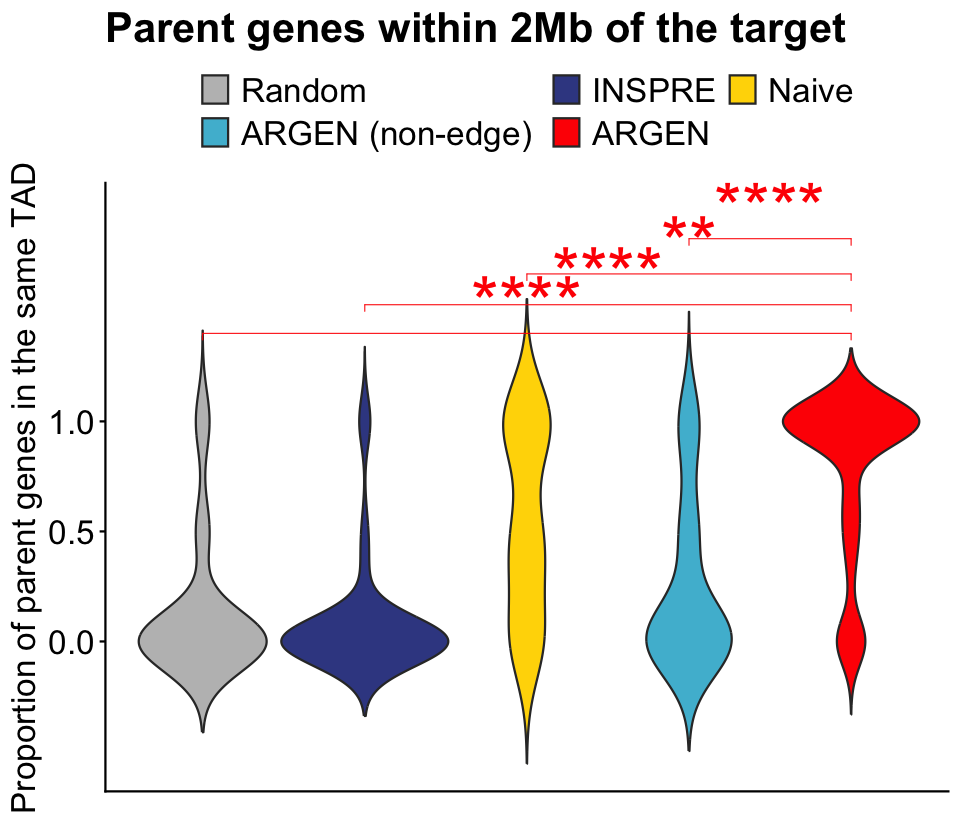

In [10]:
options(repr.plot.width = 8, repr.plot.height = 7)
# ---- Updated comparisons ----
comp_blue <- list(
  c("Random", "INSPRE"),
  c("Random", "Naive")
)

# Rename "Significant" to "ARGEN" and "Not Significant" to "ARGEN (non-edge)"
comp_red <- list(
  c("Random", "ARGEN"),
  c("INSPRE", "ARGEN"),
  c("Naive", "ARGEN"),
  c("ARGEN (non-edge)", "ARGEN")
)

# ---- More distinct y positions ----

# ---- Data Preparation (Updated Labels) ----
tmpdat <- data.frame( 
  group = factor(rep(c("ARGEN", "ARGEN (non-edge)", "Random", "INSPRE", "Naive"), 
                     each = nrow(sum_all_nonzero))), 
  value = c(sum_all_nonzero$prop_same_TAD, 
            sum_all_nonzero$prop_same_TAD_notsig, 
            sum_all_nonzero$prop_same_TAD_null, 
            sum_all_nonzero$prop_same_TAD_inspre, 
            sum_all_nonzero$prop_same_TAD_Naive) 
) 
y_max <- max(tmpdat$value, na.rm = TRUE)
y_blue <- y_max * c(1.10, 1.23)
y_red  <- y_max * c(1.35, 1.48, 1.62, 1.78)

# Reorder levels for the x-axis
tmpdat$group <- factor(tmpdat$group, 
                       levels = c("Random", "INSPRE", "Naive", "ARGEN (non-edge)", "ARGEN"))

# ---- Visualization ----
ggplot(tmpdat, aes(x = group, y = value, fill = group)) +
  geom_violin(trim = FALSE, alpha = 1, width = 1.03) +
  # Map the colors to the new names
  scale_fill_manual(values = c(
    "Random" = "gray",
    "INSPRE" = "#3B4992",
    "Naive" = "gold",
    "ARGEN (non-edge)" = "#4DBBD5",
    "ARGEN" = "red"
  )) +
  scale_color_manual(values = c(
    "Random" = "gray",
    "INSPRE" = "#3B4992",
    "Naive" = "gold",
    "ARGEN (non-edge)" = "#4DBBD5",
    "ARGEN" = "red"
  )) +
  labs(x = "", y = "Proportion of parent genes in the same TAD", 
       title = "Parent genes within 2Mb of the target") +

  # --- RED: all the rest (Updated comparison names)
  stat_compare_means(
    comparisons = comp_red,
    method = "wilcox.test",
    alternative = "greater",
    label = "p.signif",
    label.y = y_red,
    size = 15,
    method.args = list(alternative = "less"),
    color = "red"
  ) +

  theme_classic(base_size = 14) +
  theme(
    legend.position = "top",
    axis.text.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.text  = element_text(size = 20),
    axis.title = element_text(size = 20),
    plot.title = element_text(size = 25, face = "bold"),
    legend.text = element_text(size = 20),
    legend.title = element_blank()
  ) +
  scale_y_continuous(
    breaks = c(0, 0.5, 1),
    limits = c(NA, max(y_red) * 1.1)
  ) + 
  guides(
    fill = guide_legend(nrow = 2, byrow = TRUE)
  )

# Chip-seq evaluation (Fig. 5d)

## Add null edges and assemble DAG/INSPRE/Naive edges across chromosomes

## helpers for the assembling

In [11]:
# =========================================================
# 3) Helper utilities
#    - pick_col: find first matching alias in names
# =========================================================
pick_col <- function(nm, aliases, fallback = NULL) {
  cand <- intersect(aliases, nm)
  if (length(cand)) cand[1] else fallback
}

# =========================================================
# 4) Safe converter for one edge df
#    Input df may have 'from'/'to' under various aliases; keeps BOTH:
#      * from_id, to_id
#      * from_name_raw, to_name_raw (original symbols)
#      * from_name, to_name         (fallbacked display names)
# =========================================================
convert_edges <- function(df) {
  if (is.null(df)) return(NULL)
  if (!is.data.frame(df)) df <- as.data.frame(df, stringsAsFactors = FALSE)
  if (!nrow(df)) return(df)
  
  nm <- names(df)
  
  # common aliases; if missing, fall back to first two columns
  from_aliases <- c("from", "source", "src", "parent", "u")
  to_aliases   <- c("to",   "target", "dst", "child",  "v")
  
  from_col <- pick_col(nm, from_aliases, fallback = if (length(nm) >= 1) nm[1] else NULL)
  to_col   <- pick_col(nm, to_aliases,   fallback = if (length(nm) >= 2) nm[2] else NULL)
  if (is.null(from_col) || is.null(to_col)) {
    stop("convert_edges(): couldn't identify 'from'/'to' columns in an edge frame.")
  }
  
  coef_col <- if ("coef" %in% nm) "coef" else NULL
  pval_col <- if ("p_raw" %in% nm) "p_raw" else NULL      
  
  out <- tibble(
    from_id = as.character(df[[from_col]]),
    to_id   = as.character(df[[to_col]]),
    coef    = if (!is.null(coef_col)) suppressWarnings(as.numeric(df[[coef_col]])) else NA_real_,
    p_raw    = if (!is.null(pval_col)) suppressWarnings(as.numeric(df[[pval_col]])) else NA_real_        
  )
  
  # attach original symbols and fallbacked display names
  out <- out %>%
    left_join(id2name, by = c("from_id" = "gene_id")) %>%
    dplyr::rename(from_name_raw = gene) %>%
    left_join(id2name, by = c("to_id" = "gene_id")) %>%
    dplyr::rename(to_name_raw = gene) %>%
    mutate(
      from_name = if_else(is.na(from_name_raw) | from_name_raw == "", from_id, from_name_raw),
      to_name   = if_else(is.na(to_name_raw)   | to_name_raw   == "", to_id,   to_name_raw)
    ) %>%
    dplyr::select(from_id, to_id, from_name_raw, to_name_raw, from_name, to_name, coef,p_raw)
  
  out
}


## Assembling step.

In [12]:
edges_all_names_both_allchr=NULL
sig_edges_allchr=NULL

for(chr in c(1:23)){
  chrlist=paste0('chr',c(1:22,"X"))
  DAG_DIR <- paste0(DIR,'/results/application/chr_specific/',chrlist[chr])
  setwd(DAG_DIR)
  dag_artifact=readRDS(file = 'dag_0.05BH_0.05onlineBH.rds')
  meta_data <- readRDS(paste0(DIR,'/data/chr_specific/',chrlist[chr],"/meta_data_",chrlist[chr],'.rds'))
  sig_edges=dag_artifact$dag_edges
  sig_edges=sig_edges %>%   mutate(edge_id=paste0(from,"_",to))    
  sig_edges_allchr=rbind(sig_edges_allchr,sig_edges)
  
  id2name <- meta_data %>%
    distinct(gene_id, gene) %>%
    mutate(across(everything(), as.character))    
  
  if(chr!=13){dag_artifact_inspre=readRDS(file = paste0('result_INSPRE.rds'))}
  
  
  dag_artifact_Naive=readRDS(file = paste0("Naive_dag_0.05BH_0.05onlineBH.rds"))    
  
  
  
  
  
  edge_structure_named <- do.call('rbind',dag_artifact$dag_object$edge_structure_all) %>% convert_edges
  edge_structure_Naive_named <- do.call('rbind',dag_artifact_Naive$dag_object$edge_structure) %>% convert_edges    
  edge_structure_inspre_named <- do.call('rbind',dag_artifact_inspre$edge_structure) %>% convert_edges    
  
  edges_named_all <- edge_structure_named  %>%
    group_by(from_id, to_id) %>%
    slice_max(order_by = abs(coef), with_ties = FALSE) %>%
    ungroup()
  
  
  
  
  ######################    
  # generate null edges#
  ######################    
  nodes=unique(c(edge_structure_named$from_id,edge_structure_named$to_id))
  edges_df=edge_structure_named %>% mutate(from=from_id,to=to_id)
  
  # fast edge key helpers
  edge_key <- function(a, b) paste0(a, "->", b)
  E_called <- unique(edge_key(edges_df$from, edges_df$to))
  
  # ensure everything is inside the node universe & drop self-loops if any slipped in
  edges_df <- subset(edges_df, from %in% nodes & to %in% nodes & from != to)
  E_called <- unique(edge_key(edges_df$from, edges_df$to))
  n_called <- length(E_called)
  
  make_null_uniform <- function(nodes, E_called, m = length(E_called), seed = 1) {
    set.seed(seed)
    # all directed pairs except self-loops
    all_pairs <- expand.grid(from = nodes, to = nodes, stringsAsFactors = FALSE)
    all_pairs <- subset(all_pairs, from != to)
    # exclude called edges
    all_pairs$key <- paste0(all_pairs$from, "->", all_pairs$to)
    pool <- subset(all_pairs, !(key %in% E_called))
    if (nrow(pool) < m) stop("Not enough edges in the background pool to sample.")
    samp <- pool[sample.int(nrow(pool), m, replace = FALSE), c("from","to")]
    rownames(samp) <- NULL
    samp
  }
  
  null_uniform <- make_null_uniform(nodes, E_called, m = n_called, seed = 1)
  null_uniform=cbind(null_uniform,coef=0)
  edge_structure_null_named=null_uniform %>% convert_edges    
  
  edges_named_all_null <- edge_structure_null_named  %>%
    group_by(from_id, to_id) %>%
    slice_max(order_by = abs(coef), with_ties = FALSE) %>%
    ungroup()
  
  ######################        
  
  # =========================================================
  # 6) Output objects
  #    - result list + handy derived tables
  # =========================================================
  
  edges_all_names_both_null <- edges_named_all_null %>%
    transmute(
      from_id, from_name_raw, from_name,
      to_id,   to_name_raw,   to_name,
      coef,p_raw
    )        
  
  
  
  # Handy views (choose what you need):
  edges_all_names_both <- edges_named_all %>%
    transmute(
      from_id, from_name_raw, from_name,
      to_id,   to_name_raw,   to_name,
      coef,p_raw
    )    
  
  if(dim(edge_structure_inspre_named)[1]!=0){
    edges_named_inspre <- edge_structure_inspre_named  %>%
      group_by(from_id, to_id) %>%
      slice_max(order_by = abs(coef), with_ties = FALSE) %>%
      ungroup()
    
    
    
    edges_all_names_both_inspre <- edges_named_inspre %>%
      transmute(
        from_id, from_name_raw, from_name,
        to_id,   to_name_raw,   to_name,
        coef,p_raw
      )        
    
    
  }    
  
  if(dim(edge_structure_Naive_named)[1]!=0){
    edges_named_Naive <- edge_structure_Naive_named  %>%
      group_by(from_id, to_id) %>%
      slice_max(order_by = abs(coef), with_ties = FALSE) %>%
      ungroup()
    
    
    
    edges_all_names_both_Naive <- edges_named_Naive %>%
      transmute(
        from_id, from_name_raw, from_name,
        to_id,   to_name_raw,   to_name,
        coef,p_raw
      )        
    
    
  }    
  
  
  
  
  
  edges_all_names_both=edges_all_names_both %>% mutate(method="ProxyIV")
  edges_all_names_both_null=edges_all_names_both_null %>% mutate(method="Random")
  edges_all_names_both_inspre=edges_all_names_both_inspre %>% mutate(method="INSPRE") 
  edges_all_names_both_Naive=edges_all_names_both_Naive %>% mutate(method="Naive")    
  
  
  
  edges_all_names_both_and_null=rbind(edges_all_names_both,edges_all_names_both_null)   
  
  
  
  edges_all_names_both_allchr=rbind(edges_all_names_both_allchr,edges_all_names_both_and_null,edges_all_names_both_inspre,edges_all_names_both_Naive)
}
edges_all_names_both_allchr$p_raw[is.na(edges_all_names_both_allchr$p_raw)]=1# assign p-value=1 for NAs


## Read in coordinate information

In [13]:
edges_with_coords=readRDS(paste0(DIR,'/data/auxiliary/edges_with_coords.rds'))

## Build promoter windows and overlap with ChIP-seq peaks

Computes ChIP-seq peak co-occurrence per TF for edge classes: Not Significant, Random, Significant (ARGEN), INSPRE, and Naive GLM.

In [14]:
# --- parameters (edit as you like) ---
PROM_UP   <- 1000   # bp upstream of TSS
PROM_DOWN <- 0    # bp downstream of TSS

qcut_off = -log(0.05, 10)

# chr normalizer: ensure exactly one 'chr' prefix (vectorized)
normalize_chr <- function(v) {
  v <- as.character(v)
  v[v == "" | is.na(v)] <- NA_character_
  core <- v
  has_pref <- !is.na(core) & substr(core, 1L, 3L) == "chr"
  core[has_pref] <- substring(core[has_pref], 4L)
  ifelse(is.na(core), NA_character_, paste0("chr", core))
}

# --- build promoters (adds columns, keeps originals) ---
edges_with_promoters <- edges_with_coords %>%
  mutate(
    # coerce types
    tss_from   = as.integer(tss_from),
    tss_to     = as.integer(tss_to),
    strand_from = as.character(strand_from),
    strand_to   = as.character(strand_to),

    # FROM-gene promoter (+: [TSS-UP, TSS+DOWN], -: [TSS-DOWN, TSS+UP])
    chr_from_prom   = normalize_chr(chr_from),
    start_from_prom = if_else(is.na(tss_from), NA_integer_,
                              if_else(strand_from == "-",
                                      pmax(1L, tss_from - PROM_DOWN),
                                      pmax(1L, tss_from - PROM_UP))),
    end_from_prom   = if_else(is.na(tss_from), NA_integer_,
                              if_else(strand_from == "-",
                                      tss_from + PROM_UP,
                                      tss_from + PROM_DOWN)),

    # TO-gene promoter
    chr_to_prom   = normalize_chr(chr_to),
    start_to_prom = if_else(is.na(tss_to), NA_integer_,
                            if_else(strand_to == "-",
                                    pmax(1L, tss_to - PROM_DOWN),
                                    pmax(1L, tss_to - PROM_UP))),
    end_to_prom   = if_else(is.na(tss_to), NA_integer_,
                            if_else(strand_to == "-",
                                    tss_to + PROM_UP,
                                    tss_to + PROM_DOWN))
  )

# --- if you only want the TO-side promoters as a compact table ---
to_promoters <- edges_with_promoters %>%
  transmute(
    from_id, from_name, to_id, to_name, coef, p_raw,
    chr_to_prom, start_to_prom, end_to_prom, method
  )

# --- or only FROM-side promoters ---
from_promoters <- edges_with_promoters %>%
  transmute(
    from_id, from_name, to_id, to_name, coef, p_raw,
    chr_from_prom, start_from_prom, end_from_prom, method
  )

colnames(to_promoters)[7:9]   = c("chr_to","start_to","end_to")
colnames(from_promoters)[7:9] = c("chr_from","start_from","end_from")


from_promoters  = from_promoters %>% mutate(edge_id = paste0(from_id,"_",to_id))
to_promoters    = to_promoters   %>% mutate(edge_id = paste0(from_id,"_",to_id))
annotated_promoters          = to_promoters
annotated_promoters$chr_from = from_promoters$chr_from
annotated_promoters$start_from = from_promoters$start_from
annotated_promoters$end_from   = from_promoters$end_from

################################
#### Not significant ones ####
################################

tfg = stringr::word(list.files(paste0(DIR,'/data/chipseq/')), 1, sep = '.bed')

output = data.table()
out_each_protein_not_sig = list()

norm_chr <- function(x) paste0("chr", sub("^chr", "", as.character(x)))

for (which_TF in tfg) {

  # ---------------- your original edge filtering ----------------
  edges_with_coefs = annotated_promoters %>%
    filter(!edge_id %in% sig_edges_allchr$edge_id & p_raw != 1 & method == "ProxyIV")

  # -------------------- pk block (UNCHANGED) --------------------
  chipseq_peak = data.table::fread(paste0(DIR,'/data/chipseq/', which_TF, '.bed'))
  if (which_TF == "H3K27ac") { chipseq_peak = chipseq_peak[V9 > qcut_off]; min(chipseq_peak$V9) %>% print }
  pk <- as.data.table(chipseq_peak)
  setnames(pk, old = names(pk)[1:10],
           new = c("chr","start0","end","name","score","strand","signal","pvalue","qvalue","peak_idx"))

  pk = pk[qvalue > qcut_off]

  # convert to 1-based inclusive to match gene coordinates (GTF)
  pk[, start := as.integer(start0 + 1L)]
  pk[, end   := as.integer(end)]  # already 1-based end
  pk[, chr   := paste0("chr", sub("^chr", "", as.character(chr)))]

  # keep only valid intervals
  pk <- pk[!is.na(chr) & !is.na(start) & !is.na(end) & start <= end]
  setkey(pk, chr, start, end)
  # ------------------ end pk block (UNCHANGED) ------------------

  # ---- FROM intervals from edges ----
  ed_from <- as.data.table(edges_with_coefs)[, .(
    edge_id, from_id, from_name, to_id, to_name, coef,
    chr = norm_chr(chr_from),
    start = as.integer(start_from),
    end   = as.integer(end_from)
  )]
  ed_from <- ed_from[!is.na(chr) & !is.na(start) & !is.na(end) & start <= end]
  setkey(ed_from, chr, start, end)

  # ---- TO intervals from edges ----
  ed_to <- as.data.table(edges_with_coefs)[, .(
    edge_id, from_id, from_name, to_id, to_name, coef,
    chr = norm_chr(chr_to),
    start = as.integer(start_to),
    end   = as.integer(end_to)
  )]
  ed_to <- ed_to[!is.na(chr) & !is.na(start) & !is.na(end) & start <= end]
  setkey(ed_to, chr, start, end)

  # ---- overlaps: peaks vs FROM and vs TO ----
  hits_from <- foverlaps(pk, ed_from, by.x = c("chr","start","end"),
                         by.y = c("chr","start","end"),
                         type = "any", nomatch = 0L)

  hits_to <- foverlaps(pk, ed_to, by.x = c("chr","start","end"),
                       by.y = c("chr","start","end"),
                       type = "any", nomatch = 0L)

  # ---- summarize per edge_id ----
  summ_from <- hits_from[, .(
    n_peaks_from     = .N,
    max_signal_from  = max(signal, na.rm = TRUE),
    avg_signal_from  = mean(signal, na.rm = TRUE)
  ), by = .(edge_id)]

  summ_to <- hits_to[, .(
    n_peaks_to     = .N,
    max_signal_to  = max(signal, na.rm = TRUE),
    avg_signal_to  = mean(signal, na.rm = TRUE)
  ), by = .(edge_id)]

  # ---- join back and create flags ----
  ed <- as.data.table(edges_with_coefs)
  ed <- merge(ed, summ_from, by = "edge_id", all.x = TRUE)
  ed <- merge(ed, summ_to,   by = "edge_id", all.x = TRUE)

  ed[, n_peaks_from   := fifelse(is.na(n_peaks_from), 0L, n_peaks_from)]
  ed[, n_peaks_to     := fifelse(is.na(n_peaks_to),   0L, n_peaks_to)]
  ed[, has_peak_from  := n_peaks_from > 0L]
  ed[, has_peak_to    := n_peaks_to   > 0L]
  ed[, has_peak_both  := has_peak_from & has_peak_to]

  ed[, max_signal_from := ifelse(is.infinite(max_signal_from), NA_real_, max_signal_from)]
  ed[, max_signal_to   := ifelse(is.infinite(max_signal_to),   NA_real_, max_signal_to)]

  output <- rbindlist(list(output, ed), use.names = TRUE, fill = TRUE)
  out_each_protein_not_sig[[which_TF]] <- ed
}

################################
#### Random edges ####
################################

tfg = stringr::word(list.files(paste0(DIR,'/data/chipseq/')), 1, sep = '.bed')


output = data.table()
out_each_protein_random = list()

norm_chr <- function(x) paste0("chr", sub("^chr", "", as.character(x)))

for (which_TF in tfg) {

  # ---------------- your original edge filtering ----------------
  edges_with_coefs = annotated_promoters %>%
    filter(!edge_id %in% sig_edges_allchr$edge_id & p_raw == 1 & method == "Random")

  # -------------------- pk block (UNCHANGED) --------------------
  chipseq_peak = data.table::fread(paste0(DIR,'/data/chipseq/', which_TF, '.bed'))
  if (which_TF == "H3K27ac") { chipseq_peak = chipseq_peak[V9 > qcut_off]; min(chipseq_peak$V9) %>% print }
  pk <- as.data.table(chipseq_peak)
  setnames(pk, old = names(pk)[1:10],
           new = c("chr","start0","end","name","score","strand","signal","pvalue","qvalue","peak_idx"))

  pk = pk[qvalue > qcut_off]

  # convert to 1-based inclusive to match gene coordinates (GTF)
  pk[, start := as.integer(start0 + 1L)]
  pk[, end   := as.integer(end)]  # already 1-based end
  pk[, chr   := paste0("chr", sub("^chr", "", as.character(chr)))]

  # keep only valid intervals
  pk <- pk[!is.na(chr) & !is.na(start) & !is.na(end) & start <= end]
  setkey(pk, chr, start, end)
  # ------------------ end pk block (UNCHANGED) ------------------

  # ---- FROM intervals from edges ----
  ed_from <- as.data.table(edges_with_coefs)[, .(
    edge_id, from_id, from_name, to_id, to_name, coef,
    chr = norm_chr(chr_from),
    start = as.integer(start_from),
    end   = as.integer(end_from)
  )]
  ed_from <- ed_from[!is.na(chr) & !is.na(start) & !is.na(end) & start <= end]
  setkey(ed_from, chr, start, end)

  # ---- TO intervals from edges ----
  ed_to <- as.data.table(edges_with_coefs)[, .(
    edge_id, from_id, from_name, to_id, to_name, coef,
    chr = norm_chr(chr_to),
    start = as.integer(start_to),
    end   = as.integer(end_to)
  )]
  ed_to <- ed_to[!is.na(chr) & !is.na(start) & !is.na(end) & start <= end]
  setkey(ed_to, chr, start, end)

  # ---- overlaps: peaks vs FROM and vs TO ----
  hits_from <- foverlaps(pk, ed_from, by.x = c("chr","start","end"),
                         by.y = c("chr","start","end"),
                         type = "any", nomatch = 0L)

  hits_to <- foverlaps(pk, ed_to, by.x = c("chr","start","end"),
                       by.y = c("chr","start","end"),
                       type = "any", nomatch = 0L)

  # ---- summarize per edge_id ----
  summ_from <- hits_from[, .(
    n_peaks_from     = .N,
    max_signal_from  = max(signal, na.rm = TRUE),
    avg_signal_from  = mean(signal, na.rm = TRUE)
  ), by = .(edge_id)]

  summ_to <- hits_to[, .(
    n_peaks_to     = .N,
    max_signal_to  = max(signal, na.rm = TRUE),
    avg_signal_to  = mean(signal, na.rm = TRUE)
  ), by = .(edge_id)]

  # ---- join back and create flags ----
  ed <- as.data.table(edges_with_coefs)
  ed <- merge(ed, summ_from, by = "edge_id", all.x = TRUE)
  ed <- merge(ed, summ_to,   by = "edge_id", all.x = TRUE)

  ed[, n_peaks_from   := fifelse(is.na(n_peaks_from), 0L, n_peaks_from)]
  ed[, n_peaks_to     := fifelse(is.na(n_peaks_to),   0L, n_peaks_to)]
  ed[, has_peak_from  := n_peaks_from > 0L]
  ed[, has_peak_to    := n_peaks_to   > 0L]
  ed[, has_peak_both  := has_peak_from & has_peak_to]

  ed[, max_signal_from := ifelse(is.infinite(max_signal_from), NA_real_, max_signal_from)]
  ed[, max_signal_to   := ifelse(is.infinite(max_signal_to),   NA_real_, max_signal_to)]

  output <- rbindlist(list(output, ed), use.names = TRUE, fill = TRUE)
  out_each_protein_random[[which_TF]] <- ed
}

############################
## Significant ones ########
############################



output = data.table()
out_each_protein_sig = list()

norm_chr <- function(x) paste0("chr", sub("^chr", "", as.character(x)))

for (which_TF in tfg) {

  # ---------------- your original edge filtering ----------------
  edges_with_coefs = annotated_promoters %>%
    filter(edge_id %in% sig_edges_allchr$edge_id & method == "ProxyIV")

  # -------------------- pk block (UNCHANGED) --------------------
  chipseq_peak = data.table::fread(paste0(DIR,'/data/chipseq/', which_TF, '.bed'))
  if (which_TF == "H3K27ac") { chipseq_peak = chipseq_peak[V9 > qcut_off]; min(chipseq_peak$V9) %>% print }
  pk <- as.data.table(chipseq_peak)
  setnames(pk, old = names(pk)[1:10],
           new = c("chr","start0","end","name","score","strand","signal","pvalue","qvalue","peak_idx"))

  pk = pk[qvalue > qcut_off]

  # convert to 1-based inclusive to match gene coordinates (GTF)
  pk[, start := as.integer(start0 + 1L)]
  pk[, end   := as.integer(end)]  # already 1-based end
  pk[, chr   := paste0("chr", sub("^chr", "", as.character(chr)))]

  # keep only valid intervals
  pk <- pk[!is.na(chr) & !is.na(start) & !is.na(end) & start <= end]
  setkey(pk, chr, start, end)
  # ------------------ end pk block (UNCHANGED) ------------------

  # ---- FROM intervals from edges ----
  ed_from <- as.data.table(edges_with_coefs)[, .(
    edge_id, from_id, from_name, to_id, to_name, coef,
    chr = norm_chr(chr_from),
    start = as.integer(start_from),
    end   = as.integer(end_from)
  )]
  ed_from <- ed_from[!is.na(chr) & !is.na(start) & !is.na(end) & start <= end]
  setkey(ed_from, chr, start, end)

  # ---- TO intervals from edges ----
  ed_to <- as.data.table(edges_with_coefs)[, .(
    edge_id, from_id, from_name, to_id, to_name, coef,
    chr = norm_chr(chr_to),
    start = as.integer(start_to),
    end   = as.integer(end_to)
  )]
  ed_to <- ed_to[!is.na(chr) & !is.na(start) & !is.na(end) & start <= end]
  setkey(ed_to, chr, start, end)

  # ---- overlaps: peaks vs FROM and vs TO ----
  hits_from <- foverlaps(pk, ed_from, by.x = c("chr","start","end"),
                         by.y = c("chr","start","end"),
                         type = "any", nomatch = 0L)

  hits_to <- foverlaps(pk, ed_to, by.x = c("chr","start","end"),
                       by.y = c("chr","start","end"),
                       type = "any", nomatch = 0L)

  # ---- summarize per edge_id ----
  summ_from <- hits_from[, .(
    n_peaks_from     = .N,
    max_signal_from  = max(signal, na.rm = TRUE),
    avg_signal_from  = mean(signal, na.rm = TRUE)
  ), by = .(edge_id)]

  summ_to <- hits_to[, .(
    n_peaks_to     = .N,
    max_signal_to  = max(signal, na.rm = TRUE),
    avg_signal_to  = mean(signal, na.rm = TRUE)
  ), by = .(edge_id)]

  # ---- join back and create flags ----
  ed <- as.data.table(edges_with_coefs)
  ed <- merge(ed, summ_from, by = "edge_id", all.x = TRUE)
  ed <- merge(ed, summ_to,   by = "edge_id", all.x = TRUE)

  ed[, n_peaks_from   := fifelse(is.na(n_peaks_from), 0L, n_peaks_from)]
  ed[, n_peaks_to     := fifelse(is.na(n_peaks_to),   0L, n_peaks_to)]
  ed[, has_peak_from  := n_peaks_from > 0L]
  ed[, has_peak_to    := n_peaks_to   > 0L]
  ed[, has_peak_both  := has_peak_from & has_peak_to]

  ed[, max_signal_from := ifelse(is.infinite(max_signal_from), NA_real_, max_signal_from)]
  ed[, max_signal_to   := ifelse(is.infinite(max_signal_to),   NA_real_, max_signal_to)]

  output <- rbindlist(list(output, ed), use.names = TRUE, fill = TRUE)
  out_each_protein_sig[[which_TF]] <- ed
}

############################
## INSPRE ########
############################


output = data.table()
out_each_protein_INSPRE = list()

norm_chr <- function(x) paste0("chr", sub("^chr", "", as.character(x)))

for (which_TF in tfg) {

  # ---------------- your original edge filtering ----------------
  edges_with_coefs = annotated_promoters %>%
    filter(method == "INSPRE")

  # -------------------- pk block (UNCHANGED) --------------------
  chipseq_peak = data.table::fread(paste0(DIR,'/data/chipseq/', which_TF, '.bed'))
  if (which_TF == "H3K27ac") { chipseq_peak = chipseq_peak[V9 > qcut_off]; min(chipseq_peak$V9) %>% print }
  pk <- as.data.table(chipseq_peak)
  setnames(pk, old = names(pk)[1:10],
           new = c("chr","start0","end","name","score","strand","signal","pvalue","qvalue","peak_idx"))

  pk = pk[qvalue > qcut_off]

  # convert to 1-based inclusive to match gene coordinates (GTF)
  pk[, start := as.integer(start0 + 1L)]
  pk[, end   := as.integer(end)]  # already 1-based end
  pk[, chr   := paste0("chr", sub("^chr", "", as.character(chr)))]

  # keep only valid intervals
  pk <- pk[!is.na(chr) & !is.na(start) & !is.na(end) & start <= end]
  setkey(pk, chr, start, end)
  # ------------------ end pk block (UNCHANGED) ------------------

  # ---- FROM intervals from edges ----
  ed_from <- as.data.table(edges_with_coefs)[, .(
    edge_id, from_id, from_name, to_id, to_name, coef,
    chr = norm_chr(chr_from),
    start = as.integer(start_from),
    end   = as.integer(end_from)
  )]
  ed_from <- ed_from[!is.na(chr) & !is.na(start) & !is.na(end) & start <= end]
  setkey(ed_from, chr, start, end)

  # ---- TO intervals from edges ----
  ed_to <- as.data.table(edges_with_coefs)[, .(
    edge_id, from_id, from_name, to_id, to_name, coef,
    chr = norm_chr(chr_to),
    start = as.integer(start_to),
    end   = as.integer(end_to)
  )]
  ed_to <- ed_to[!is.na(chr) & !is.na(start) & !is.na(end) & start <= end]
  setkey(ed_to, chr, start, end)

  # ---- overlaps: peaks vs FROM and vs TO ----
  hits_from <- foverlaps(pk, ed_from, by.x = c("chr","start","end"),
                         by.y = c("chr","start","end"),
                         type = "any", nomatch = 0L)

  hits_to <- foverlaps(pk, ed_to, by.x = c("chr","start","end"),
                       by.y = c("chr","start","end"),
                       type = "any", nomatch = 0L)

  # ---- summarize per edge_id ----
  summ_from <- hits_from[, .(
    n_peaks_from     = .N,
    max_signal_from  = max(signal, na.rm = TRUE),
    avg_signal_from  = mean(signal, na.rm = TRUE)
  ), by = .(edge_id)]

  summ_to <- hits_to[, .(
    n_peaks_to     = .N,
    max_signal_to  = max(signal, na.rm = TRUE),
    avg_signal_to  = mean(signal, na.rm = TRUE)
  ), by = .(edge_id)]

  # ---- join back and create flags ----
  ed <- as.data.table(edges_with_coefs)
  ed <- merge(ed, summ_from, by = "edge_id", all.x = TRUE)
  ed <- merge(ed, summ_to,   by = "edge_id", all.x = TRUE)

  ed[, n_peaks_from   := fifelse(is.na(n_peaks_from), 0L, n_peaks_from)]
  ed[, n_peaks_to     := fifelse(is.na(n_peaks_to),   0L, n_peaks_to)]
  ed[, has_peak_from  := n_peaks_from > 0L]
  ed[, has_peak_to    := n_peaks_to   > 0L]
  ed[, has_peak_both  := has_peak_from & has_peak_to]

  ed[, max_signal_from := ifelse(is.infinite(max_signal_from), NA_real_, max_signal_from)]
  ed[, max_signal_to   := ifelse(is.infinite(max_signal_to),   NA_real_, max_signal_to)]

  output <- rbindlist(list(output, ed), use.names = TRUE, fill = TRUE)
  out_each_protein_INSPRE[[which_TF]] <- ed
}





############################
## Naive ########
############################



output = data.table()
out_each_protein_Naive = list()

norm_chr <- function(x) paste0("chr", sub("^chr", "", as.character(x)))

for (which_TF in tfg) {
  
  # ---------------- your original edge filtering ----------------
  edges_with_coefs = annotated_promoters %>%
    filter(method == "Naive")
  
  # -------------------- pk block (UNCHANGED) --------------------
  chipseq_peak = data.table::fread(paste0(DIR,'/data/chipseq/', which_TF, '.bed'))
  if (which_TF == "H3K27ac") { chipseq_peak = chipseq_peak[V9 > qcut_off]; min(chipseq_peak$V9) %>% print }
  pk <- as.data.table(chipseq_peak)
  setnames(pk, old = names(pk)[1:10],
           new = c("chr","start0","end","name","score","strand","signal","pvalue","qvalue","peak_idx"))
  
  pk = pk[qvalue > qcut_off]
  
  # convert to 1-based inclusive to match gene coordinates (GTF)
  pk[, start := as.integer(start0 + 1L)]
  pk[, end   := as.integer(end)]  # already 1-based end
  pk[, chr   := paste0("chr", sub("^chr", "", as.character(chr)))]
  
  # keep only valid intervals
  pk <- pk[!is.na(chr) & !is.na(start) & !is.na(end) & start <= end]
  setkey(pk, chr, start, end)
  # ------------------ end pk block (UNCHANGED) ------------------
  
  # ---- FROM intervals from edges ----
  ed_from <- as.data.table(edges_with_coefs)[, .(
    edge_id, from_id, from_name, to_id, to_name, coef,
    chr = norm_chr(chr_from),
    start = as.integer(start_from),
    end   = as.integer(end_from)
  )]
  ed_from <- ed_from[!is.na(chr) & !is.na(start) & !is.na(end) & start <= end]
  setkey(ed_from, chr, start, end)
  
  # ---- TO intervals from edges ----
  ed_to <- as.data.table(edges_with_coefs)[, .(
    edge_id, from_id, from_name, to_id, to_name, coef,
    chr = norm_chr(chr_to),
    start = as.integer(start_to),
    end   = as.integer(end_to)
  )]
  ed_to <- ed_to[!is.na(chr) & !is.na(start) & !is.na(end) & start <= end]
  setkey(ed_to, chr, start, end)
  
  # ---- overlaps: peaks vs FROM and vs TO ----
  hits_from <- foverlaps(pk, ed_from, by.x = c("chr","start","end"),
                         by.y = c("chr","start","end"),
                         type = "any", nomatch = 0L)
  
  hits_to <- foverlaps(pk, ed_to, by.x = c("chr","start","end"),
                       by.y = c("chr","start","end"),
                       type = "any", nomatch = 0L)
  
  # ---- summarize per edge_id ----
  summ_from <- hits_from[, .(
    n_peaks_from     = .N,
    max_signal_from  = max(signal, na.rm = TRUE),
    avg_signal_from  = mean(signal, na.rm = TRUE)
  ), by = .(edge_id)]
  
  summ_to <- hits_to[, .(
    n_peaks_to     = .N,
    max_signal_to  = max(signal, na.rm = TRUE),
    avg_signal_to  = mean(signal, na.rm = TRUE)
  ), by = .(edge_id)]
  
  # ---- join back and create flags ----
  ed <- as.data.table(edges_with_coefs)
  ed <- merge(ed, summ_from, by = "edge_id", all.x = TRUE)
  ed <- merge(ed, summ_to,   by = "edge_id", all.x = TRUE)
  
  ed[, n_peaks_from   := fifelse(is.na(n_peaks_from), 0L, n_peaks_from)]
  ed[, n_peaks_to     := fifelse(is.na(n_peaks_to),   0L, n_peaks_to)]
  ed[, has_peak_from  := n_peaks_from > 0L]
  ed[, has_peak_to    := n_peaks_to   > 0L]
  ed[, has_peak_both  := has_peak_from & has_peak_to]
  
  ed[, max_signal_from := ifelse(is.infinite(max_signal_from), NA_real_, max_signal_from)]
  ed[, max_signal_to   := ifelse(is.infinite(max_signal_to),   NA_real_, max_signal_to)]
  
  output <- rbindlist(list(output, ed), use.names = TRUE, fill = TRUE)
  out_each_protein_Naive[[which_TF]] <- ed
}

[1] 1.30484
[1] 1.30484
[1] 1.30484
[1] 1.30484
[1] 1.30484


# Fig. 5d

Warning message in geom_rect(data = panel_bg, inherit.aes = FALSE, aes(xmin = -Inf, :
“All aesthetics have length 1, but the data has 6 rows.
ℹ Please consider using `annotate()` or provide this layer with data containing a single row.”


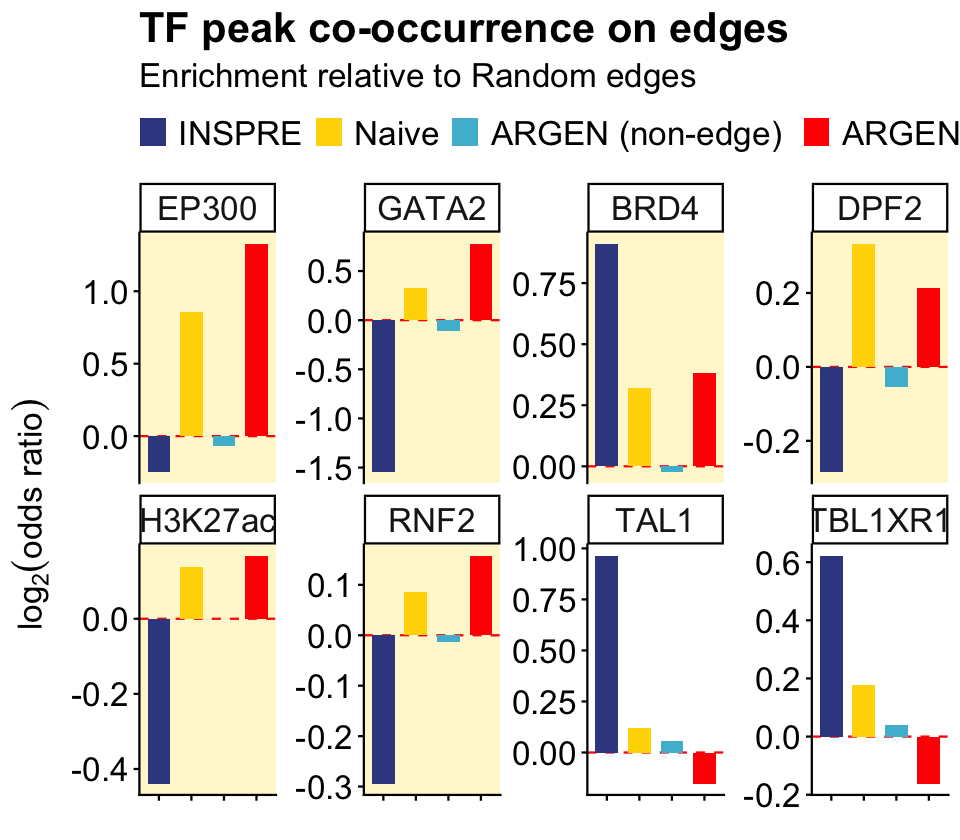

In [15]:
options(repr.plot.width = 8, repr.plot.height = 7)

# -----------------------------------------------------------
# 1) Build counts (k successes, n trials) for every protein & class
# -----------------------------------------------------------

count_one_list <- function(lst, group_label) {
  tibble(
    Protein = names(lst),
    k = map_int(lst, ~ sum(as.logical(.x$has_peak_both), na.rm = TRUE)),
    n = map_int(lst, ~ sum(!is.na(.x$has_peak_both)))
  ) %>%
    mutate(Class = group_label)
}

# Updated Labels here
counts_sig     <- count_one_list(out_each_protein_sig,      "ARGEN")
counts_not     <- count_one_list(out_each_protein_not_sig,  "ARGEN (non-edge)")
counts_random  <- count_one_list(out_each_protein_random,   "Random")
counts_INSPRE  <- count_one_list(out_each_protein_INSPRE,   "INSPRE")
counts_Naive   <- count_one_list(out_each_protein_Naive,    "Naive")

counts_all <- bind_rows(counts_sig, counts_not, counts_random, counts_INSPRE, counts_Naive) %>%
  arrange(Protein, Class)

# keep proteins that appear in all 5 classes and have n>0
counts_all <- counts_all %>%
  group_by(Protein) %>%
  filter(n() == 5, all(n > 0)) %>%
  ungroup()

# -----------------------------------------------------------
# 2) Compute ODDS and log2(odds ratio) vs Random
# -----------------------------------------------------------

df_log2or <- counts_all %>%
  group_by(Protein) %>%
  mutate(
    p = k / n,
    odds        = (k + 0.5) / (n - k + 0.5),
    odds_random = odds[Class == "Random"],
    OR          = odds / odds_random,
    log2_OR     = log2(OR)
  ) %>%
  ungroup() %>%
  mutate(
    Class = factor(Class,
                   levels = c("Random", "INSPRE", "Naive", "ARGEN (non-edge)", "ARGEN"))
  )

# -----------------------------------------------------------
# 3) Order proteins by log2_OR of ARGEN class (descending)
# -----------------------------------------------------------

protein_order <- df_log2or %>%
  filter(Class == "ARGEN") %>%
  arrange(desc(log2_OR)) %>%
  pull(Protein)

df_log2or$Protein <- factor(df_log2or$Protein, levels = protein_order)

# -----------------------------------------------------------
# 4) Mark which TFs have "ARGEN" as the greatest log2_OR
# -----------------------------------------------------------

sig_is_greatest <- df_log2or %>%
  group_by(Protein) %>%
  summarize(
    sig_max = (log2_OR[Class == "ARGEN"] > 0),
    .groups = "drop"
  )

df_log2or <- df_log2or %>%
  left_join(sig_is_greatest, by = "Protein")

# this small data.frame is for panel highlighting
panel_bg <- sig_is_greatest %>%
  filter(sig_max) %>%
  dplyr::select(Protein)

# -----------------------------------------------------------
# 5) Faceted barplot (with highlighted panels)
# -----------------------------------------------------------

p_log2or_bar <- ggplot(df_log2or %>% filter(Class != "Random"),
                       aes(x = Class,
                           y = log2_OR,
                           fill = Class)) +
  # light panel background where ARGEN is positive
  geom_rect(
    data = panel_bg,
    inherit.aes = FALSE,
    aes(xmin = -Inf, xmax = Inf, ymin = -Inf, ymax = Inf),
    fill = "lightgoldenrod1", alpha = 0.4
  ) +
  geom_hline(yintercept = 0, linetype = "dashed", col = "red") +
  geom_col(width = 0.7) +
  facet_wrap(~ Protein, nrow = 2, scales = "free_y") +
  labs(
    title    = "TF peak co-occurrence on edges",
    subtitle = "Enrichment relative to Random edges",
    y        = expression(log[2]("odds ratio")),
    x        = "",
    fill     = ""
  ) +
  scale_fill_manual(values = c(
    "ARGEN"            = "red",
    "ARGEN (non-edge)" = "#4DBBD5",
    "Random"           = "gray60",
    "INSPRE"           = "#3B4992",
    "Naive"            = "gold"
  )) +
  theme_classic(base_size = 14) +
  theme(
    plot.title    = element_text(size = 25, face = "bold"),
    plot.subtitle = element_text(size = 20),
    strip.text    = element_text(size = 20),
    axis.text.x   = element_blank(),
    axis.text.y   = element_text(size = 20),
    axis.title.y  = element_text(size = 20),
    legend.position = "top",
    legend.text      = element_text(size = 20)
  )

p_log2or_bar